# 通过首次感染时间从随机试验中估计疫苗效力

## 执行摘要

## 从随机试验中估计疫苗效力

一项关键的 III 期疫苗试验将受试者按 1:1 随机分配到**疫苗**组或**安慰剂**组,并对每个人随访直至其首次经实验室确诊的感染,或直至在入组和随访窗口结束时进行行政删失。监管上的主要终点是**疫苗效力(VE)**,其定义为 `VE = 1 - hazard ratio (vaccine vs. placebo)`。由于受试者按错开的时间表入组且大多数人从未被感染,数据是右删失的,因此生存分析方法——而非简单的比例——给出站得住脚的估计。

本笔记本在一个合成的均衡试验(**100 名受试者,疫苗组 50 名、安慰剂组 50 名**)上端到端地完成该终点分析:

- **PROC FREQ** 构建发病率的二乘二表(组别 × 感染状态),配以卡方检验、相对风险和风险差——这是临床评审者最先看到的描述性“粗略 VE”视图。
- **PROC MEANS** 汇总人时(总随访天数和平均随访天数)以及各组的原始感染计数,揭示促使采用事件时间模型的删失不平衡。
- **PROC LIFETEST** 按组别估计 Kaplan-Meier 生存曲线,并运行**对数秩(log-rank)和 Wilcoxon** 齐性检验——这是对曲线分离的非参数确认。
- **PROC PHREG** 拟合校正了年龄、性别和基线暴露风险的 Cox 比例风险模型,报告风险比及其 95% 置信限,`HAZARDRATIO` 语句直接刻画组别对比。校正后的 VE 读作 `1 - HR`。

**如何解读结果。** 在经过验证的运行中,粗略感染比例为**安慰剂组 64% 对疫苗组 30%**(卡方 p = 0.0007),对数秩检验拒绝生存曲线相等(χ² = 11.25,p = 0.0008),疫苗 vs. 安慰剂的校正 Cox 风险比为 **0.369**,95% CI 为 **(0.198, 0.687)**——完全低于 1——即估计的 VE 约为 **63%**(`1 - 0.369`)。HR 置信上限 0.687 对应约 31% 的效力下界,处于对如此小规模研究而言常规的 30-50% 许可阈值的边缘。基线高暴露职业使感染风险约增至三倍(HR = 3.47,p < .0001),证实协变量校正确有意义;年龄和性别带有临界效应(p ≈ 0.06),在 0.05 水平上未达显著。粗略二乘二表、分离的 KM 曲线与校正后的 Cox 估计三者的一致性,正是数据安全监查委员会在宣布效力之前所期望的三角互证。

*仅为合成数据——由 `streaminit`/`rand` 内联生成;无外部文件或网络。运行时间远低于一分钟。*

## 数据来源

**合成数据集 `trial`** —— 每个入组受试者一行,在第一个代码单元中内联生成(种子 `20260605`)。100 名受试者,按 1:1 均衡(疫苗组 50 名、安慰剂组 50 名),感染时间服从指数分布,疫苗组风险降低约 70%,入组时间错开,并在 540 天窗口结束时进行行政删失。

| 变量 | 类型 | 描述 |
|----------|------|-------------|
| `subjid` | Num | 受试者标识符(1-100) |
| `arm` | Char | 治疗组:`Vaccine` 或 `Placebo` |
| `arm_n` | Num | 数值型组别标志(1 = 疫苗,0 = 安慰剂) |
| `age` | Num | 入组时的年龄(岁)(18-85) |
| `sex` | Char | 性别:`F` 或 `M` |
| `baseline_risk` | Num | 高暴露职业指示变量(1 = 是) |
| `fu_days` | Num | 至首次感染或删失的随访时间(天) |
| `infected` | Num | 事件指示变量:1 = 观察到感染,0 = 删失 |

# 从随机试验中估计疫苗效力

**首次感染时间的生存分析**

疫苗试验的主要效力终点是疫苗组相对于安慰剂组的**感染风险**。我们定义

$$\text{VE} = 1 - \text{HR}_{\text{vaccine vs. placebo}}$$

由于受试者按错开的时间表入组,且大多数人在随访结束前从未被感染,数据是右删失的:简单的感染比例比较浪费了时间信息,并因随访不均衡而产生偏倚。因此,我们分三层构建估计——粗略的发病率二乘二表、带对数秩检验的非参数 Kaplan-Meier 曲线,以及校正后的 Cox 比例风险模型——并核查这三者讲述同一个故事。

本分析使用 **PROC FREQ**、**PROC MEANS**、**PROC LIFETEST** 和 **PROC PHREG**。

## 1. 生成合成试验

我们模拟一个均衡的 100 名受试者、1:1 随机化试验(疫苗组 50 名、安慰剂组 50 名——按受试者奇偶性分配,使两组完全相等)。首次感染时间从指数分布中抽取,其每日风险取决于组别(疫苗将风险降至安慰剂的 30%)、年龄以及高暴露职业标志。错开入组加上固定的 540 天窗口产生了真实的右删失:任何在其随访结束时仍未被感染的人都被删失。

In [1]:
/* Synthetic randomized vaccine trial: time to first infection */
数据 trial;
    调用 streaminit(20260605);
    enroll_days = 540;            /* enrollment + follow-up window */
    循环 subjid = 1 到 100;
        /* 1:1 randomization to vaccine vs placebo: 50 per arm,
           assigned by alternating parity for an exactly balanced trial */
        如果 mod(subjid, 2) = 1 那么 循环;
            arm = 'Vaccine'; arm_n = 1;
        结束;
        否则 循环;
            arm = 'Placebo'; arm_n = 0;
        结束;

        /* baseline covariates */
        AGE = round(rand('NORMAL', 47, 14));
        如果 AGE < 18 那么 AGE = 18;
        如果 AGE > 85 那么 AGE = 85;
        如果 rand('BERNOULLI', 0.52) = 1 那么 sex = 'F'; 否则 sex = 'M';
        baseline_risk = rand('BERNOULLI', 0.30);   /* high-exposure occupation */

        /* per-day infection hazard: placebo baseline, vaccine cuts it ~70% */
        base_rate = 0.0016;
        rr_age  = EXP(0.012 * (AGE - 47));
        rr_risk = 1 + 0.9 * baseline_risk;
        如果 arm_n = 1 那么 ve_factor = 0.30; 否则 ve_factor = 1.0;
        daily_hazard = base_rate * rr_age * rr_risk * ve_factor;

        /* time to first infection from exponential hazard */
        u = rand('UNIFORM');
        t_inf = -LOG(u) / daily_hazard;

        /* administrative censoring at staggered entry */
        entry  = rand('INTEGER', 0, 120);
        t_cens = enroll_days - entry;

        如果 t_inf <= t_cens 那么 循环;
            fu_days = round(t_inf);
            infected = 1;
        结束;
        否则 循环;
            fu_days = round(t_cens);
            infected = 0;
        结束;
        如果 fu_days < 1 那么 fu_days = 1;
        输出;
    结束;
    保留 subjid arm arm_n AGE sex baseline_risk fu_days infected;
运行;

NOTE: DATA trial


NOTE: Wrote trial (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. 发病率二乘二表

最简单的效力视图:将组别与感染状态交叉制表。卡方检验询问感染是否独立于组别;`RELRISK` 报告相对风险和优势比;`RISKDIFF` 给出带置信区间的绝对风险差。这是*粗略*(未校正、忽略随访)的图景——作为合理性核查很有用,但并非监管估计。

                                                   The FREQ Procedure

Table of ARM by INFECTED

ARM     |         0 |         1 |      Total
--------+-----------+-----------+-----------
Placebo |        18 |        32 |         50
--------+-----------+-----------+-----------
Vaccine |        35 |        15 |         50
--------+-----------+-----------+-----------
Total   |        53 |        47 |        100

Statistics for Table of ARM by INFECTED

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                1 11.6018       0.0007
Likelihood Ratio Chi-Square               1 11.8410       0.0006
Fisher's Exact Test                                      0.0012

Phi Coefficient                      0.3406
Contingency Coefficient              0.3224
Cramer's V                           0.3406


Column 1 Risk Estimates

Risk (Row 1)                         0.3600
Risk (Row 2)         

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_infected.spec.json
NOTE: PROC FREQ statement used.


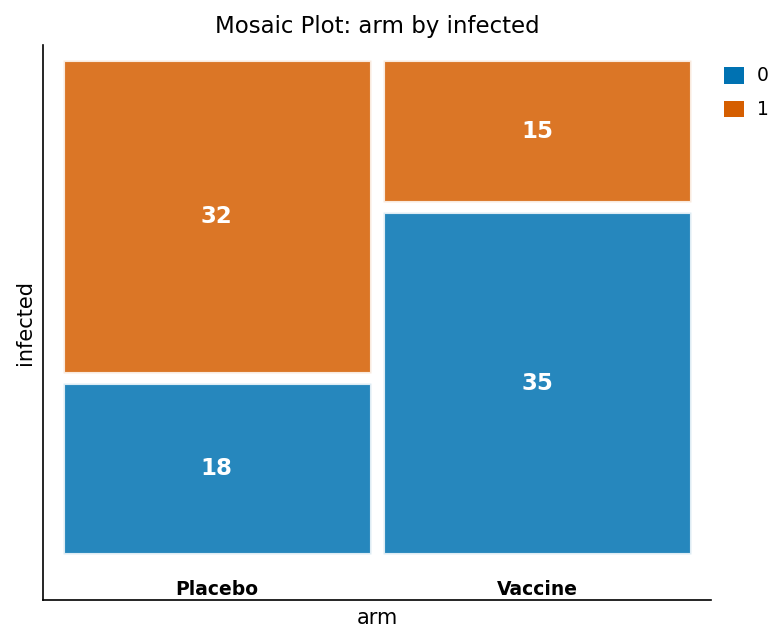

In [2]:
过程 频率 数据=trial;
    TABLES arm*infected / chisq relrisk riskdiff nocol nopercent;
运行;

## 3. 各组的人时与事件计数

在信任粗略二乘二表之前,我们先量化随访的不平衡。`PROC MEANS` 报告每组的总随访天数、平均随访天数以及感染计数。如果疫苗组累积了*更多*人时(早期事件更少),那么粗略比例会低估效力——这正是我们接下来转向事件时间模型的原因。

In [3]:
过程 均值 数据=trial n sum mean maxdec=2;
    分类 arm;
    变量 fu_days infected;
运行;

                                                  The MEANS Procedure

                                              Analysis Variable : FU_DAYS

        ARM               N Obs            Sum           Mean
        -----------------------------------------------------
        Placebo              50       14552.00         291.04
        Vaccine              50       19438.00         388.76
        -----------------------------------------------------

                                              Analysis Variable : INFECTED

        ARM               N Obs            Sum           Mean
        -----------------------------------------------------
        Placebo              50          32.00           0.64
        Vaccine              50          15.00           0.30
        -----------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Kaplan-Meier 曲线与对数秩检验

`PROC LIFETEST` 分别为每组估计乘积极限(Kaplan-Meier)生存函数——此处即随时间保持无感染的概率。`STRATA arm / test=(logrank wilcoxon)` 请求两种标准的齐性检验:**对数秩**检验对所有事件时间赋予相等权重(在比例风险下最有效),而 **Wilcoxon** 对早期事件加权更高。两者的一致性支持 Cox 模型所依赖的比例风险假设。`ATRISK` 标注仍处于风险中的数量。

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       47
Censored                    53
Median Survival Time  427.5000

    Stratum: arm = Placebo    

                             N
--------------------  --------
Total                       50
Event                       32
Censored                    18
Median Survival Time  324.0000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  9.0000    0.9800     0.0198              50                 1
 17.0000    0.9600     0.0277              49                 1
 23.0000    0.9400     0.0336              48                 1
 26.0000    0.9200     0.0384              47                 1
 39.0000    0.9000     0.0424              46                 1
 40.0000    0.8800     0.0460              45    

NOTE: PROC LIFETEST data=trial

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: lifetest_survival.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


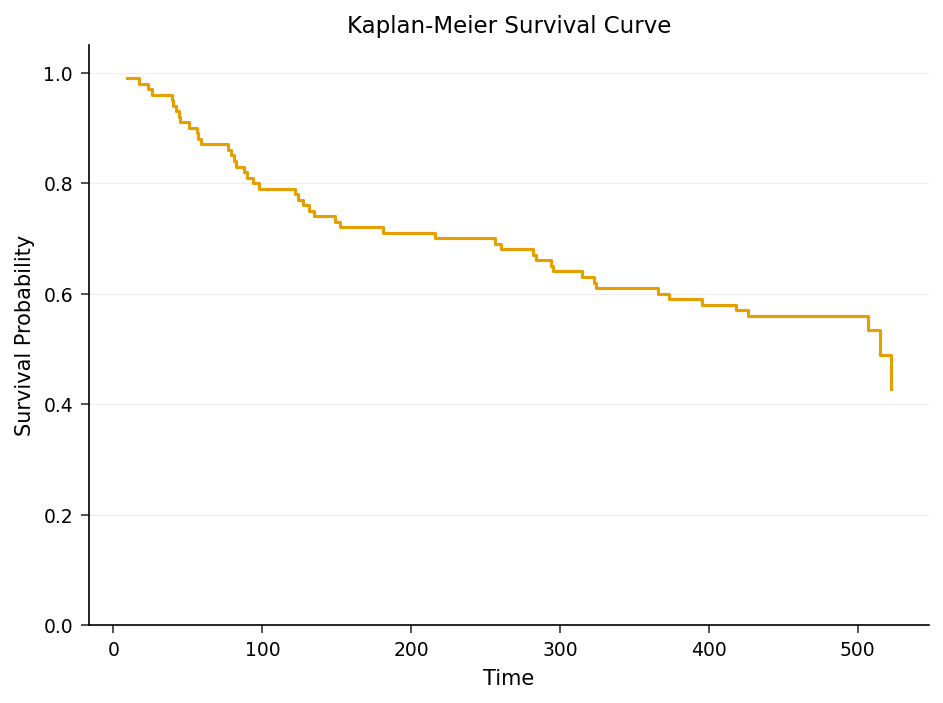

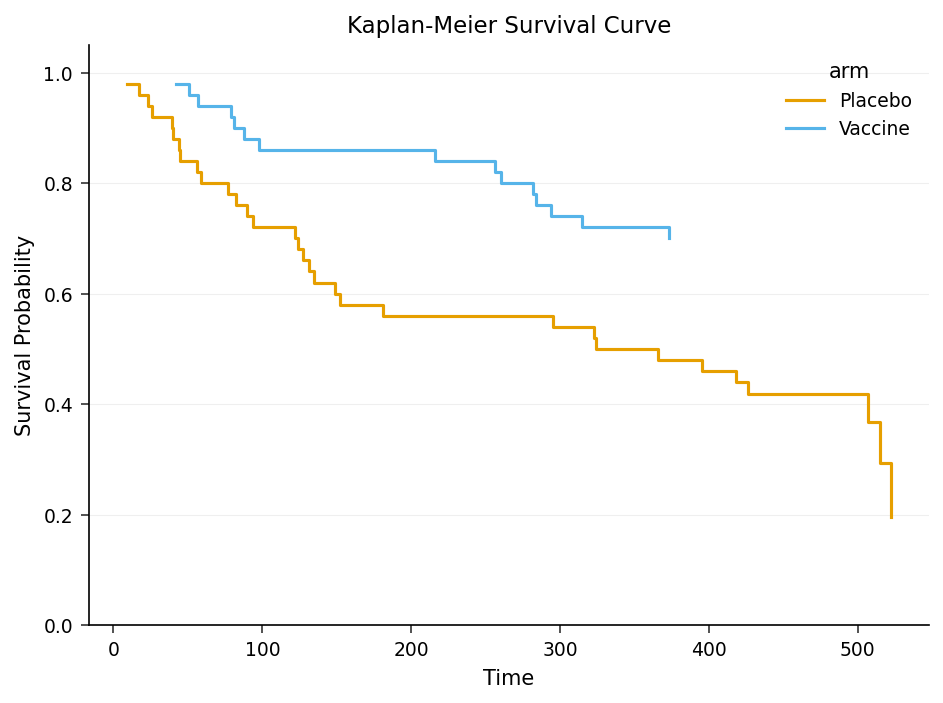

In [4]:
过程 LIFETEST 数据=trial PLOTS=SURVIVAL atrisk;
    TIME fu_days*infected(0);
    STRATA arm / TEST=(logrank WILCOXON);
运行;

## 5. 校正后的 Cox 模型与疫苗效力

Cox 比例风险模型在控制年龄、性别和基线暴露风险的情况下给出**校正后**的风险比。`CLASS arm(ref='Placebo') sex(ref='M') / param=ref` 设置参照编码,使 `ARM` 系数为疫苗 vs. 安慰剂的对数风险比。`TIES=EFRON` 是推荐的结点处理方法;`RL` 打印风险比置信限。`HAZARDRATIO` 语句报告组别对比(Wald 置信限)和每增加 10 岁的年龄效应。

**疫苗效力可直接作为组别项的 `VE = 1 - HR` 读出**,而 HR 的置信上限对应许可决策所依赖的效力下界。

In [5]:
过程 PHREG 数据=trial;
    分类 arm(REF='Placebo') sex(REF='M') / PARAM=REF;
    模型 fu_days*infected(0) = arm AGE sex baseline_risk / TIES=efron rl;
    hazardratio 'Vaccine vs Placebo' arm / cl=wald;
    hazardratio AGE / units=10;
运行;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 47
-2 LOG L                    368.882
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     29.0183         4      <.0001
Wald                 28.4562         4      <.0001
Score (Log-Rank)     30.6491         4      <.0001

                                     Analysis of Maximum Likelihood Estimates                                      

Parameter            DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
-------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------
ARM_VACCINE           1  -0.99592         0.31687    

NOTE: PROC PHREG data=trial

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 解读

这三层三角互证地指向单一的效力结论:

- **粗略发病率(PROC FREQ)。** 感染比例为**安慰剂组 64%(32/50)对疫苗组 30%(15/50)**——风险差为 **-0.34**(95% CI -0.524 至 -0.156),优势比为 **0.241**(95% CI 0.105 至 0.556)。卡方检验拒绝独立性(χ² = 11.60,p = 0.0007)。这是评审者最先期望看到的一目了然的信号——但它忽略了错开、不均衡的随访。

- **人时(PROC MEANS)。** 疫苗组的平均随访时间更长(**388.8 对 291.0 天**),正是因为更少的受试者通过感染提前退出(疫苗组 15 例事件 vs 安慰剂组 32 例)。这证实了粗略比例是一个保守的、受随访混杂的视图,并证明事件时间分析的合理性。

- **Kaplan-Meier + 对数秩(PROC LIFETEST)。** 生存曲线清晰分离——安慰剂组达到**324 天的无感染中位时间,而疫苗组的中位数未达到**(50 名接种者中仅 15 名曾被感染)。两种齐性检验均拒绝相等:**对数秩 χ² = 11.25(p = 0.0008)**、**Wilcoxon χ² = 9.11(p = 0.0025)**。二者的一致性支持 Cox 模型背后的比例风险假设。

- **校正后的 Cox 模型(PROC PHREG)。** 在校正年龄、性别和基线暴露风险后,疫苗 vs 安慰剂的风险比为 **0.369**,95% CI 为 **(0.198, 0.687)**,完全低于 1(p = 0.0017),给出约 **63% 的估计疫苗效力**(`VE = 1 - 0.369`)。效力下界(来自 HR 置信上限 0.687)约为 **31%**,处于常规 30-50% 许可阈值的边缘——正如对 100 名受试者研究所预期的那样宽。高暴露职业使感染风险约增至三倍(**HR = 3.47**,95% CI 1.90-6.35,p < .0001),证实协变量校正是有必要的;年龄(HR = 1.022/岁,p = 0.059)和女性性别(HR = 0.541,p = 0.064)带有临界效应,在 0.05 水平上未达显著。全局零假设被拒绝(似然比 χ² = 29.0,p < .0001)。

- **结论。** 由于粗略二乘二表、分离的 Kaplan-Meier 曲线以及校正后的 Cox 估计全都指向同一方向,且置信区间均排除了无效应,该试验支持一个效力信号——尽管宽的置信限反映了小样本量。在真实的申报中,Cox 的 `1 - HR` 估计及其置信区间——而非粗略比例——将作为主要终点,FREQ 与 LIFETEST 的输出则作为数据安全监查委员会一同评审的支持性描述与非参数确认。